# Delhi Air Pollution Analysis (PM2.5)

Air pollution is one of the most serious environmental and public health challenges in Delhi.  
Among various pollutants, **PM2.5** is particularly harmful because these fine particles can enter the lungs and bloodstream.

In this notebook, we perform:

• Data loading and inspection  
• Data cleaning  
• Handling missing values  
• Exploratory Data Analysis (EDA)  
• Trend and seasonal analysis of PM2.5  

The cleaned dataset will later be used for **feature engineering and machine learning modeling** to predict PM2.5 levels.

In [2]:
# Importing the essential libraries for data analysis and visualization

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Setting a consistent style for plots
sns.set_style("whitegrid")

In [3]:
# Loading the dataset
# The dataset contains daily air pollution readings for Delhi

df = pd.read_csv("../data/raw/delhi_air_quality_2020_2023.csv")

# Display the first few rows to understand the structure
df.head()

,date,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,2020-11-25 01:00:00,2616.88,2.18,70.60,13.59,38.62,364.61,411.73,28.63
1,2020-11-25 02:00:00,3631.59,23.25,89.11,0.33,54.36,420.96,486.21,41.04
2,2020-11-25 03:00:00,4539.49,52.75,100.08,1.11,68.67,463.68,541.95,49.14
3,2020-11-25 04:00:00,4539.49,50.96,111.04,6.44,78.20,454.81,534.00,48.13
4,2020-11-25 05:00:00,4379.27,42.92,117.90,17.17,87.74,448.14,529.19,46.61


In [4]:
# Checking the shape of the dataset
# This tells us how many rows and columns we have

df.shape

(18776, 9)

In [5]:
# Looking at the column names

df.columns

Index(['date', 'co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3'], dtype='object')

In [6]:
# Understanding the datatype of each column
# This is important for identifying if conversions are needed

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18776 entries, 0 to 18775
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    18776 non-null  object 
 1   co      18776 non-null  float64
 2   no      18776 non-null  float64
 3   no2     18776 non-null  float64
 4   o3      18776 non-null  float64
 5   so2     18776 non-null  float64
 6   pm2_5   18776 non-null  float64
 7   pm10    18776 non-null  float64
 8   nh3     18776 non-null  float64
dtypes: float64(8), object(1)
memory usage: 1.3+ MB


In [7]:
# Statistical summary of numerical columns

df.describe()

,co,no,no2,o3,so2,pm2_5,pm10,nh3
count,18776.000000,18776.000000,18776.000000,18776.000000,18776.000000,18776.000000,18776.000000,18776.000000
mean,2929.228628,33.660702,66.221299,60.346239,66.693633,238.130309,300.092966,25.109815
std,2854.523506,62.127118,48.527492,80.464932,49.439191,226.533625,267.165827,26.402108
min,260.350000,0.000000,4.280000,0.000000,5.250000,11.830000,15.070000,0.000000
25%,1068.120000,0.680000,33.930000,0.340000,34.810000,84.440000,118.797500,9.630000
50%,1842.500000,5.250000,54.150000,27.180000,52.930000,157.445000,209.705000,17.480000
75%,3685.000000,35.760000,83.630000,92.980000,82.020000,313.000000,387.965000,30.400000
max,21148.680000,500.680000,460.620000,801.090000,579.830000,1708.090000,1969.930000,287.770000


In [8]:
# The 'date' column should be in datetime format
# This will help us perform time-based analysis later

df["date"] = pd.to_datetime(df["date"])

In [9]:
# Sorting the dataset chronologically

df = df.sort_values("date")

In [10]:
# Checking how many missing values exist in each column

df.isnull().sum()

date     0
co       0
no       0
no2      0
o3       0
so2      0
pm2_5    0
pm10     0
nh3      0
dtype: int64

In [11]:
# Removing rows with missing values
# In real-world datasets, we may use interpolation instead

df = df.dropna()

In [12]:
df.isnull().sum()

date     0
co       0
no       0
no2      0
o3       0
so2      0
pm2_5    0
pm10     0
nh3      0
dtype: int64

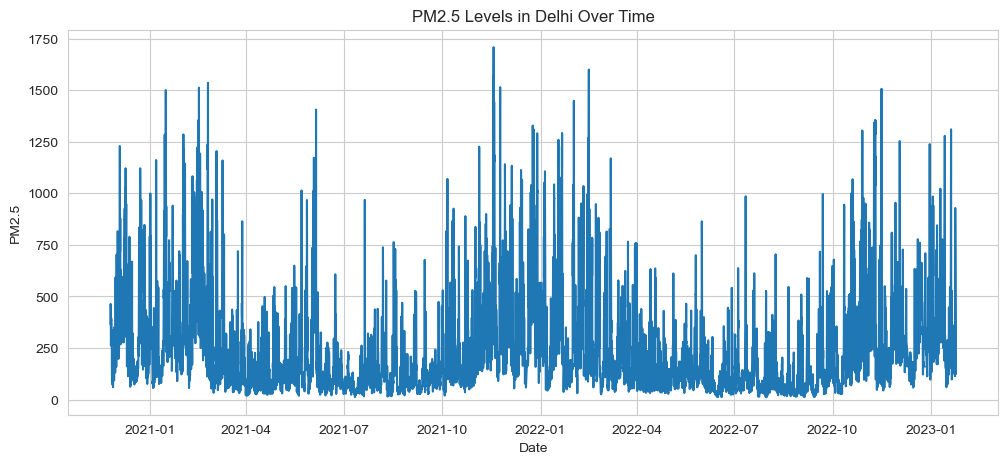

In [13]:
# Visualizing how PM2.5 levels change over time

plt.figure(figsize=(12,5))

plt.plot(df["date"], df["pm2_5"])

plt.title("PM2.5 Levels in Delhi Over Time")
plt.xlabel("Date")
plt.ylabel("PM2.5")

plt.show()

KeyError: 'pm2_5_7day_avg'

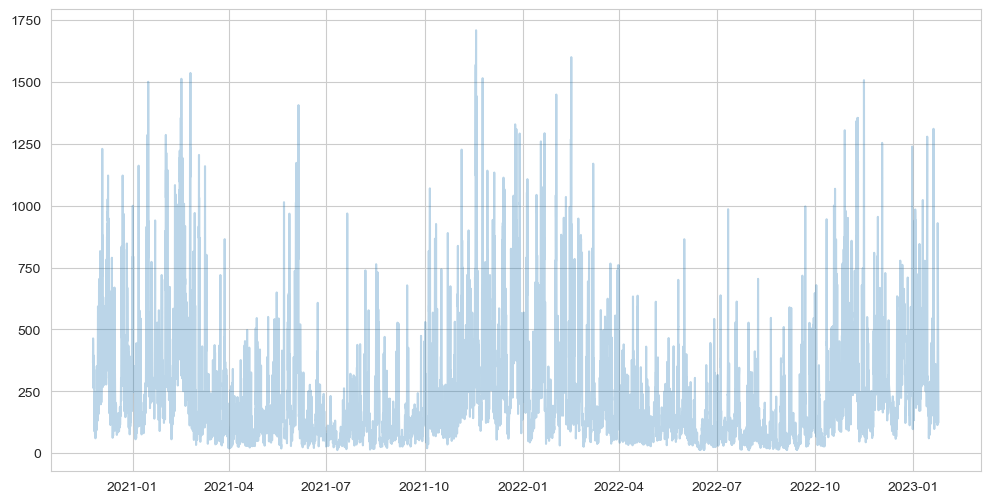

In [14]:
plt.figure(figsize=(12,6))

# Daily PM2.5 values
plt.plot(df["date"], df["pm2_5"], alpha=0.3, label="Daily PM2.5")

# 7-day moving average
plt.plot(df["date"], df["pm2_5_7day_avg"], label="7-Day Moving Average")

# 30-day moving average
plt.plot(df["date"], df["pm2_5_30day_avg"], label="30-Day Moving Average")

plt.title("PM2.5 Trend with Moving Averages")

plt.xlabel("Date")
plt.ylabel("PM2.5")

plt.legend()

plt.show()

From the plot we can observe that PM2.5 levels fluctuate significantly over time.  
There are several peaks which may correspond to **winter pollution events or smog periods**.

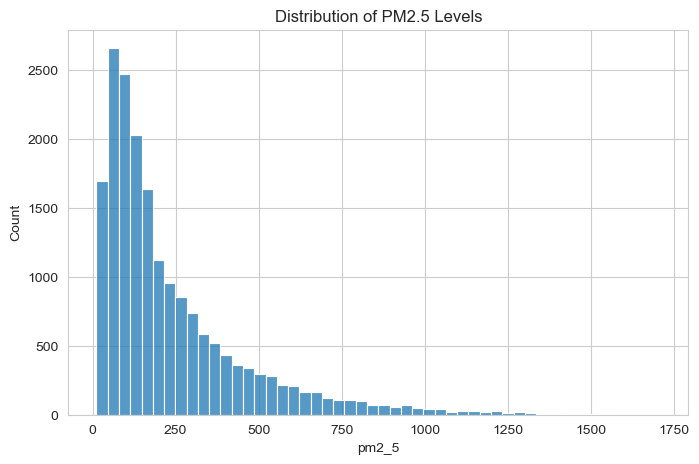

In [15]:
# Understanding how PM2.5 values are distributed

plt.figure(figsize=(8,5))

sns.histplot(df["pm2_5"], bins=50)

plt.title("Distribution of PM2.5 Levels")

plt.show()

This distribution helps us understand whether pollution levels are  
normally distributed or skewed towards higher pollution days.

In [16]:
# Creating new columns for year and month

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

In [17]:
df.head()

,date,co,no,no2,o3,so2,pm2_5,pm10,nh3,year,month
0,2020-11-25 01:00:00,2616.88,2.18,70.60,13.59,38.62,364.61,411.73,28.63,2020,11
1,2020-11-25 02:00:00,3631.59,23.25,89.11,0.33,54.36,420.96,486.21,41.04,2020,11
2,2020-11-25 03:00:00,4539.49,52.75,100.08,1.11,68.67,463.68,541.95,49.14,2020,11
3,2020-11-25 04:00:00,4539.49,50.96,111.04,6.44,78.20,454.81,534.00,48.13,2020,11
4,2020-11-25 05:00:00,4379.27,42.92,117.90,17.17,87.74,448.14,529.19,46.61,2020,11


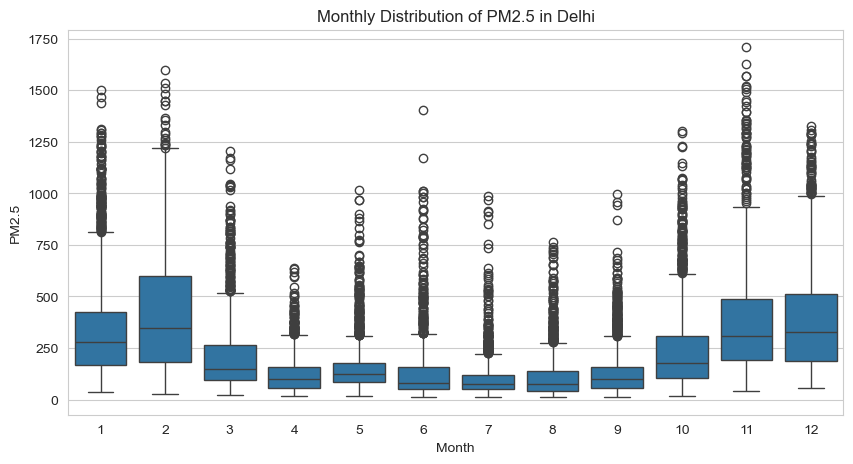

In [18]:
# Boxplot showing PM2.5 variation across different months

plt.figure(figsize=(10,5))

sns.boxplot(x="month", y="pm2_5", data=df)

plt.title("Monthly Distribution of PM2.5 in Delhi")

plt.xlabel("Month")
plt.ylabel("PM2.5")

plt.show()

Seasonal analysis often shows **higher pollution during winter months**  
due to factors such as crop burning, temperature inversion, and lower wind speeds.

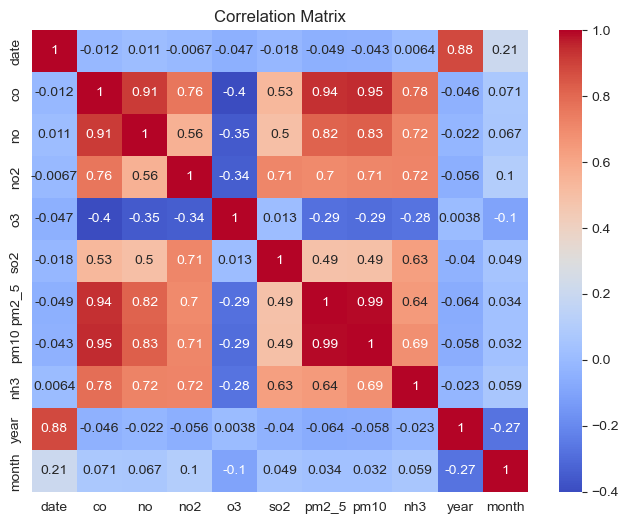

In [19]:
# Checking relationships between numerical features

plt.figure(figsize=(8,6))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

Correlation analysis helps identify which features might be useful for
building machine learning models later.

In [20]:
# Saving the cleaned dataset
# This will be used in the feature engineering and modeling notebooks

df.to_csv("../data/processed/delhi_cleaned.csv", index=False)

## Conclusion

In this notebook we performed:

• Dataset inspection  
• Data cleaning  
• Handling missing values  
• PM2.5 trend analysis  
• Moving average analysis  
• Seasonal pollution analysis  

The cleaned dataset has now been saved and will be used for **feature engineering and predictive modeling in the next notebook.**

EDA Insights

• PM2.5 shows strong seasonal variation
• Winter months exhibit significantly higher pollution levels
• Certain meteorological variables correlate with pollution spikes